In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt # Visualization
import sklearn.metrics
import statistics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


file_path = 'Cafe_2022_for_ANN.csv'
df = pd.read_csv(file_path)
df.set_index('ts', inplace=True)
display(df)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


In [3]:
scaler = StandardScaler()
linear_regressor = LinearRegression() 

x = df.drop('kW',axis = 1) 
y = df.kW

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
Fit = scaler.fit(x_train)

x_train_scaled = Fit.transform(x_train)
x_test_scaled = Fit.transform(x_test)

linear_regressor.fit(x_train_scaled, y_train)
y_predict_train = linear_regressor.predict(x_train_scaled)
y_predict_test = linear_regressor.predict(x_test_scaled)

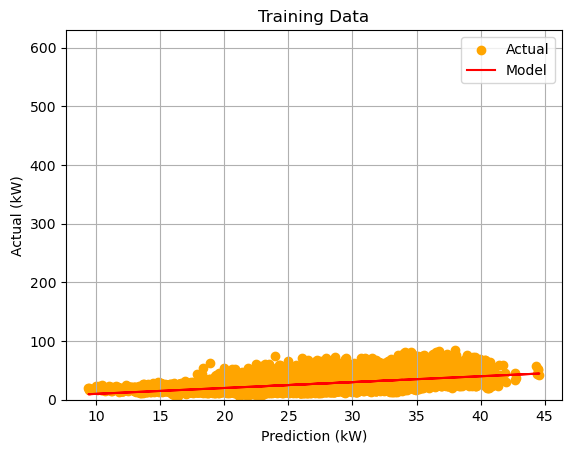

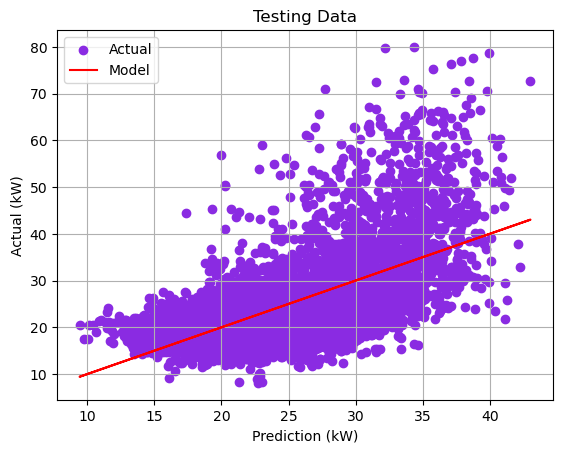

In [4]:
# Plot predicted train vs actual training data
fig,ax = plt.subplots()
ax.scatter(y_predict_train,y_train, c='orange', label='Actual')
ax.plot(y_predict_train, y_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()
ax.set_ylim([0, 630])

# Plot predicted test vs actual test data
fig,ax = plt.subplots()
ax.scatter(y_predict_test, y_test, c='blueviolet', label='Actual')
ax.plot(y_predict_test, y_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
ax.legend()
ax.grid()

In [5]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y_train, y_predict_train))
print("MSE:", mean_squared_error(y_train, y_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y_train, y_predict_train)))
print("MAE:", mean_absolute_error(y_train, y_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y_train ,y_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y_test, y_predict_test))
print("MSE:", mean_squared_error(y_test, y_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y_test, y_predict_test)))
print("MAE:", mean_absolute_error(y_test, y_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y_test, y_predict_test))

Train Data
R^2: 0.37244834918073444
MSE: 51.897853875265334
Root MSE: 7.204016509924539
MAE: 5.187866675303232
MAPE: % 0.2113328003132316
 
Test Data
R^2: 0.3668824544171677
MSE: 52.30207163212896
Root MSE: 7.232017120563872
MAE: 5.182039069257424
MAPE: % 0.212108948672109
